In [1]:
from pspy import so_map, so_spectra
import so_kspec
from pixell import enmap, enplot
import numpy as np
from matplotlib import pyplot as plt

spectra = ["TT", "TE", "TB", "ET", "BT", "EE", "EB", "BE", "BB"]
# ACT DR6 beft fit
clfile = '/global/cfs/cdirs/sobs/users/merrydup/deep56/proposal_plots/cmb.dat'
l, ps_theory = so_spectra.read_ps(clfile, spectra=spectra)
fac = l * (l + 1) / (2 * np.pi)

ps_theory_keys = {
    'T': 'TT',
    'Q': 'EE',
    'U': 'EE',
}

In [2]:

act_map_list = [enmap.read_map(f"/global/cfs/cdirs/sobs/users/merrydup/deep56/act_projected/act_dr6.02_std_AA_night_pa5_f090_4way_set{i}_map_srcfree.fits") for i in range(4)]
lwcs = enmap.lwcs(act_map_list[0].shape, act_map_list[0].wcs)

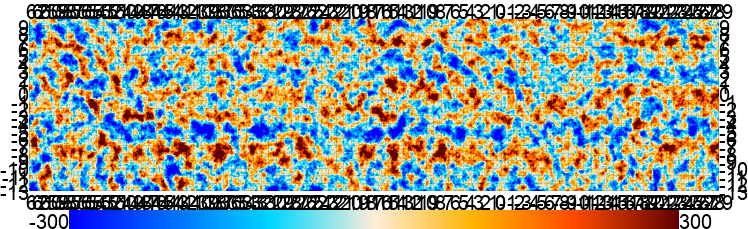

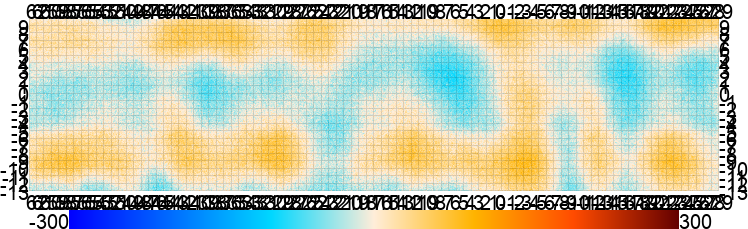

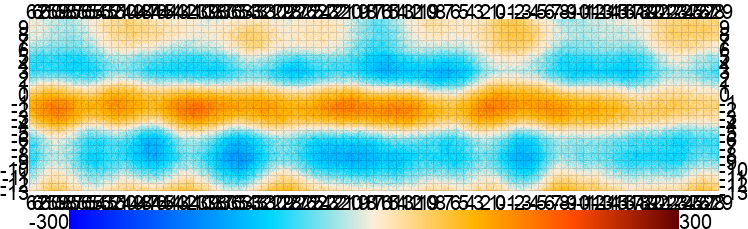

In [3]:
params = {'downgrade':16, 'colorbar':True, 'range':300}
enplot.pshow(act_map_list[0], **params)
# enplot.pshow(act_map_list[1], **params)
# enplot.pshow(act_map_list[2], **params)
# enplot.pshow(act_map_list[3], **params)

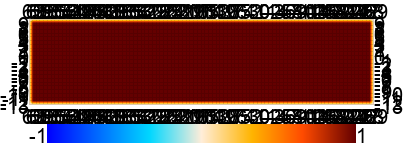

In [4]:
template = enmap.zeros(shape=(act_map_list[0].shape[-2], act_map_list[0].shape[-1]), wcs=act_map_list[0].wcs)
window = template.copy()
window += 1
window[0, :] = 0
window[-1, :] = 0
window[:, 0] = 0
window[:, -1] = 0
window = enmap.apod(window, 150)
act_map_list_window = [act_map * window for act_map in act_map_list]
enplot.pshow(window, downgrade=32, colorbar=True, range=1)


In [5]:
kspec_act_1 = so_kspec.from_enmap(act_map_list[0] * window)
kspec_act_2 = so_kspec.from_enmap(act_map_list[0]* window)

In [6]:
kspec_act_cross = so_kspec.from_enmap_list(act_map_list_window)


In [7]:
bin_edges = np.arange(0, 5050, 50)
angles_ranges = [
    [-22.5, 22.5],
    [22.5, 67.5],
    [67.5, 112.5],
    [112.5, 157.5],
]

so_kspec.make_1d_spectra_and_save(
    kspec_act_cross, 
    bins_edges=bin_edges, 
    theta_ranges=angles_ranges, 
    filename='/pscratch/sd/m/merrydup/PSpipe_merry_piso/project/SO/pISO/notebooks/1d_spectra_test.pkl'
)

all theta spectra


theta_0
theta_1
theta_2
theta_3


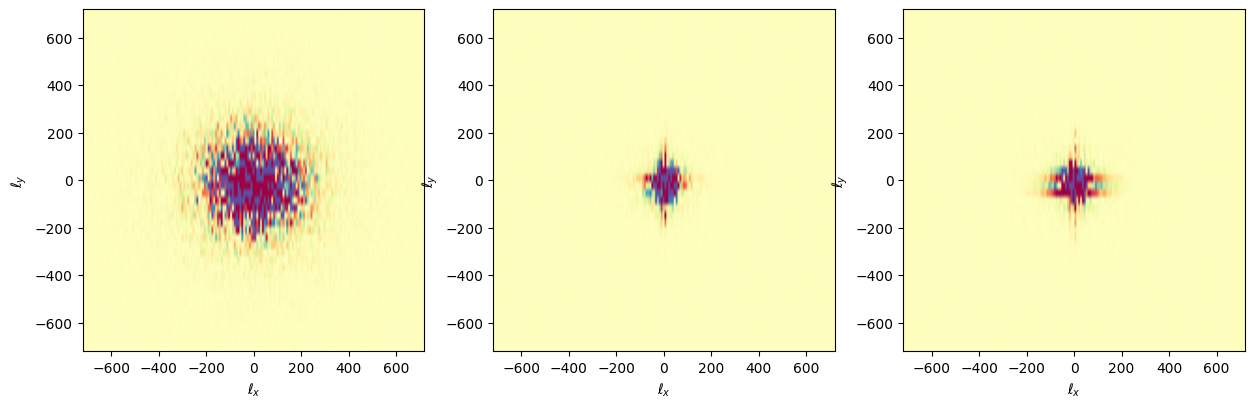

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

kspec_act_1.axplot(map_to_plot=kspec_act_1.kmaps[0][0].real, ax_to_plot=ax[0], type='Cl', TQU='T', cmap='Spectral', zoom=720, vmin=-.1, vmax=.1, downgrade=2)
kspec_act_1.axplot(map_to_plot=kspec_act_1.kmaps[0][1].real, ax_to_plot=ax[1], type='Cl', TQU='T', cmap='Spectral', zoom=720, vmin=-.1, vmax=.1, downgrade=2)
kspec_act_1.axplot(map_to_plot=kspec_act_1.kmaps[0][2].real, ax_to_plot=ax[2], type='Cl', TQU='T', cmap='Spectral', zoom=720, vmin=-.1, vmax=.1, downgrade=2)

/pscratch/sd/m/merrydup/PSpipe_merry_piso/project/SO/pISO/notebooks/so_kspec.py:90: RuntimeWarning: invalid value encountered in log10
  map_to_plot = np.log10(map_to_plot)


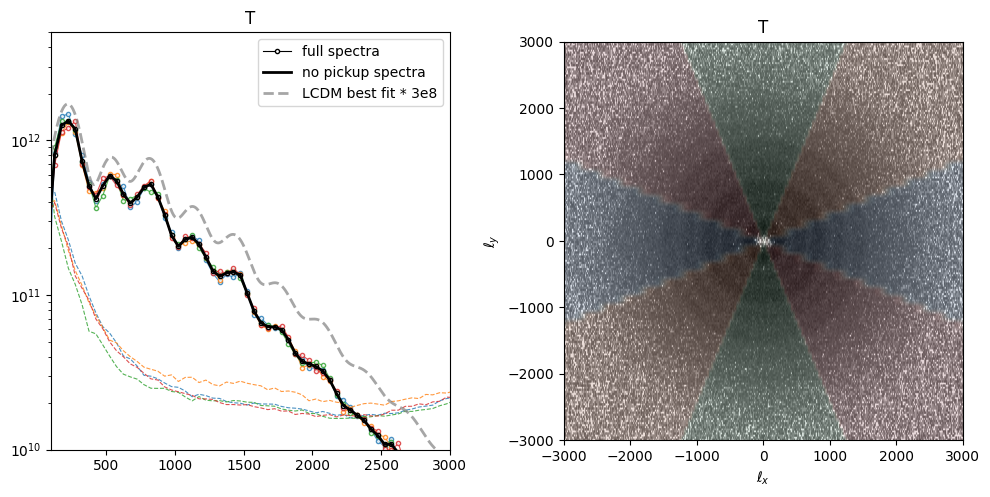

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
TQU = 'T'

kspec_act_cross.axplot(ax_to_plot=ax[1], log=True, cmap='Greys', TQU=TQU, vmin=5, vmax=13)


cmaps = [
    'Blues',
    'Oranges',
    'Greens',
    'Reds',
]
colors = [
    'C0', 'C1', 'C2', 'C3', 
]

for i, theta_range in enumerate(angles_ranges):
    ax[0].plot(*kspec_act_cross.radial_binned_1d_spec(bin_edges, theta_range=theta_range, TQU=TQU), color=colors[i], alpha=.8, lw=.8, marker='.', mfc='white', zorder=-10)
    ax[0].plot(*kspec_act_cross.radial_binned_1d_spec(bin_edges, which_map=kspec_act_cross.pow_noise, theta_range=theta_range, TQU=TQU), color=colors[i], alpha=.8, lw=.8, marker='', ls='--', mfc='white', zorder=-10)

    theta_min = theta_range[0]
    theta_max = theta_range[1]
    
    mask_direct = (kspec_act_cross.thetamap >= theta_min) & (kspec_act_cross.thetamap <= theta_max)
    mask_opposite_1 = (kspec_act_cross.thetamap >= max(theta_min - 180, -180)) & (kspec_act_cross.thetamap <= theta_max - 180)
    mask_opposite_2 = (kspec_act_cross.thetamap >= theta_min + 180) & (kspec_act_cross.thetamap <= min(theta_max + 180, 180))
    mask = enmap.enmap(np.fft.fftshift((mask_direct | mask_opposite_1 | mask_opposite_2).astype(float))).downgrade(8)
    ax[1].imshow(mask, extent=kspec_act_cross.llims, cmap=cmaps[i], alpha=mask * .15)

ls, ps = kspec_act_cross.radial_binned_1d_spec(bin_edges, TQU=TQU)
ax[0].plot(ls, ps, color='black', ls='-', label='full spectra', lw=.8, marker='.', mfc='white',)
ls, ps = kspec_act_cross.radial_binned_1d_spec(bin_edges, TQU=TQU)
ax[0].plot(ls, ps, color='black', ls='-', label='no pickup spectra', lw=2)
ax[0].plot(l, ps_theory[ps_theory_keys[TQU]] * 3e8, color='grey', ls='--', label='LCDM best fit * 3e8', lw=2, alpha=.7)
# ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylim((1e10, 5e12))
ax[0].legend()
ax[0].set_title(TQU)

zoom = 3000
ax[0].set_xlim((100, zoom))
ax[1].set_xlim(-zoom, zoom)
ax[1].set_ylim(-zoom, zoom)
ax[1].set_title(TQU)

plt.tight_layout()

/pscratch/sd/m/merrydup/PSpipe_merry_piso/project/SO/pISO/notebooks/so_kspec.py:90: RuntimeWarning: invalid value encountered in log10
  map_to_plot = np.log10(map_to_plot)


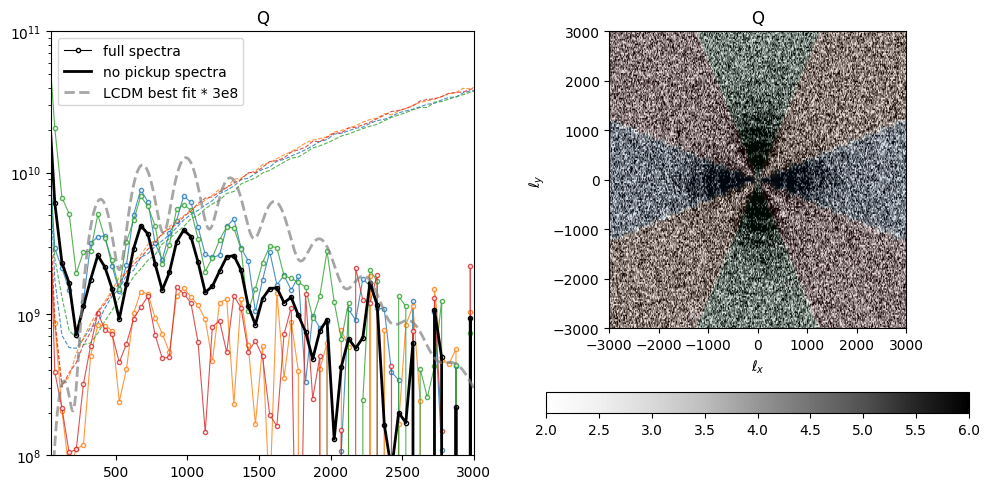

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
TQU = 'Q'


angles_ranges = [
    [-22.5, 22.5],
    [22.5, 67.5],
    [67.5, 112.5],
    [112.5, 157.5],
]

cmaps = [
    'Blues',
    'Oranges',
    'Greens',
    'Reds',
]
colors = [
    'C0', 'C1', 'C2', 'C3', 
]

kspec_act_cross.axplot(ax_to_plot=ax[1], log=True, cmap='Greys', TQU=TQU, vmin=2, vmax=6, colorbar=True)
for i, theta_range in enumerate(angles_ranges):
    ax[0].plot(*kspec_act_cross.radial_binned_1d_spec(bin_edges, theta_range=theta_range, TQU=TQU), color=colors[i], alpha=.8, lw=.8, marker='.', mfc='white', zorder=-10)
    ax[0].plot(*kspec_act_cross.radial_binned_1d_spec(bin_edges, which_map=kspec_act_cross.pow_noise, theta_range=theta_range, TQU=TQU), color=colors[i], alpha=.8, lw=.8, marker='', ls='--', mfc='white', zorder=-10)

    theta_min = theta_range[0]
    theta_max = theta_range[1]
    
    mask_direct = (kspec_act_cross.thetamap >= theta_min) & (kspec_act_cross.thetamap <= theta_max)
    mask_opposite_1 = (kspec_act_cross.thetamap >= max(theta_min - 180, -180)) & (kspec_act_cross.thetamap <= theta_max - 180)
    mask_opposite_2 = (kspec_act_cross.thetamap >= theta_min + 180) & (kspec_act_cross.thetamap <= min(theta_max + 180, 180))
    mask = enmap.enmap(np.fft.fftshift((mask_direct | mask_opposite_1 | mask_opposite_2).astype(float))).downgrade(8)
    ax[1].imshow(mask, extent=kspec_act_cross.llims, cmap=cmaps[i], alpha=mask * .15)

ls, ps = kspec_act_cross.radial_binned_1d_spec(bin_edges, TQU=TQU)
ax[0].plot(ls, ps, color='black', ls='-', label='full spectra', lw=.8, marker='.', mfc='white',)
ls, ps = kspec_act_cross.radial_binned_1d_spec(bin_edges, TQU=TQU)
ax[0].plot(ls, ps, color='black', ls='-', label='no pickup spectra', lw=2)


ax[0].plot(l, ps_theory[ps_theory_keys[TQU]] * 3e8, color='grey', ls='--', label='LCDM best fit * 3e8', lw=2, alpha=.7)
# ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylim((1e8, 1e11))
ax[0].legend()
ax[0].set_title(TQU)

zoom = 3000
ax[0].set_xlim((50, zoom))
ax[1].set_xlim(-zoom, zoom)
ax[1].set_ylim(-zoom, zoom)
ax[1].set_title(TQU)

plt.tight_layout()

/pscratch/sd/m/merrydup/PSpipe_merry_piso/project/SO/pISO/notebooks/so_kspec.py:90: RuntimeWarning: invalid value encountered in log10
  map_to_plot = np.log10(map_to_plot)


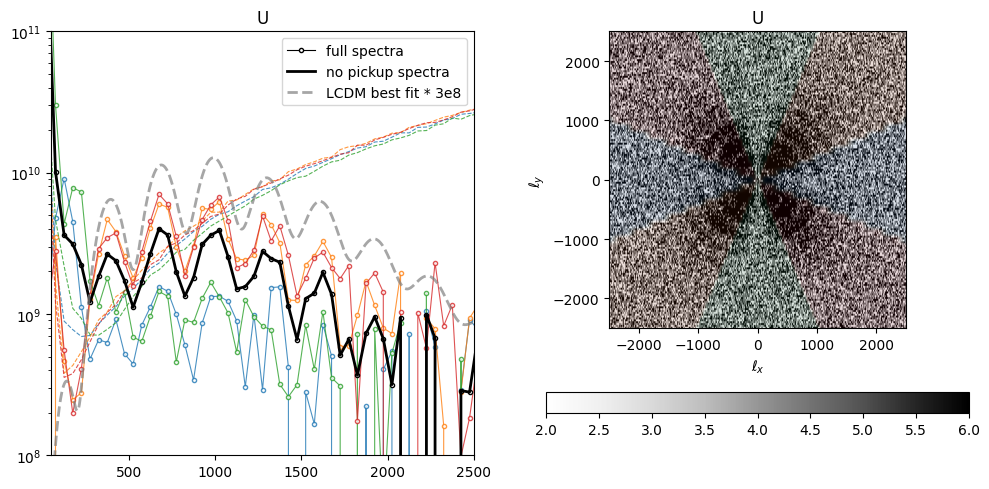

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
TQU = 'U'


angles_ranges = [
    [-22.5, 22.5],
    [22.5, 67.5],
    [67.5, 112.5],
    [112.5, 157.5],
]

cmaps = [
    'Blues',
    'Oranges',
    'Greens',
    'Reds',
]
colors = [
    'C0', 'C1', 'C2', 'C3', 
]

kspec_act_cross.axplot(ax_to_plot=ax[1], log=True, cmap='Greys', TQU=TQU, vmin=2, vmax=6, colorbar=True)
for i, theta_range in enumerate(angles_ranges):
    ax[0].plot(*kspec_act_cross.radial_binned_1d_spec(bin_edges, theta_range=theta_range, TQU=TQU), color=colors[i], alpha=.8, lw=.8, marker='.', mfc='white', zorder=-10)
    ax[0].plot(*kspec_act_cross.radial_binned_1d_spec(bin_edges, which_map=kspec_act_cross.pow_noise, theta_range=theta_range, TQU=TQU), color=colors[i], alpha=.8, lw=.8, marker='', ls='--', mfc='white', zorder=-10)

    theta_min = theta_range[0]
    theta_max = theta_range[1]
    
    mask_direct = (kspec_act_cross.thetamap >= theta_min) & (kspec_act_cross.thetamap <= theta_max)
    mask_opposite_1 = (kspec_act_cross.thetamap >= max(theta_min - 180, -180)) & (kspec_act_cross.thetamap <= theta_max - 180)
    mask_opposite_2 = (kspec_act_cross.thetamap >= theta_min + 180) & (kspec_act_cross.thetamap <= min(theta_max + 180, 180))
    mask = enmap.enmap(np.fft.fftshift((mask_direct | mask_opposite_1 | mask_opposite_2).astype(float))).downgrade(8)
    ax[1].imshow(mask, extent=kspec_act_cross.llims, cmap=cmaps[i], alpha=mask * .15)

ls, ps = kspec_act_cross.radial_binned_1d_spec(bin_edges, TQU=TQU)
ax[0].plot(ls, ps, color='black', ls='-', label='full spectra', lw=.8, marker='.', mfc='white',)
ls, ps = kspec_act_cross.radial_binned_1d_spec(bin_edges, TQU=TQU)
ax[0].plot(ls, ps, color='black', ls='-', label='no pickup spectra', lw=2)


ax[0].plot(l, ps_theory[ps_theory_keys[TQU]] * 3e8, color='grey', ls='--', label='LCDM best fit * 3e8', lw=2, alpha=.7)
# ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylim((1e8, 1e11))
ax[0].legend()
ax[0].set_title(TQU)

zoom = 2500
ax[0].set_xlim((50, zoom))
ax[1].set_xlim(-zoom, zoom)
ax[1].set_ylim(-zoom, zoom)
ax[1].set_title(TQU)

plt.tight_layout()